In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

from tree_helpers import RANDOM_STATE

In [12]:
take_partial_df = True

suffix = "_partial" * take_partial_df
path_to_train = f"../../public/data/df_train{suffix}.csv"

df_train = pd.read_csv(path_to_train)
df_test = pd.read_csv("../../public/data/df_test.csv")
df_train

,nom,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
0,Apatosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,21.0,218000,Marsh (1877),ajax,Saurischia,Diplodocidae
1,Brachiosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,30.0,50000,Riggs (1903),altithorax,Saurischia,Brachiosauridae
2,Gallimimus,carnivore,Crétacé supérieur,Mongolie,grand théropode,True,6.0,200,Osmòlska Roniewicz and Barsbold (1972),bullatus,Saurischia,Ornithomimidae
3,Megalosaurus,carnivore,Jurassique moyen,Royaume-Uni,grand théropode,True,9.0,700,Ritgen (1826),bucklandii,Saurischia,Megalosaurinae
4,Plateosaurus,herbivore,Trias supérieur,Suisse,sauropode,True,7.0,4000,Meyer (1837),engelhardti,Saurischia,Plateosauridae
5,Spinosaurus,carnivore,Crétacé supérieur,Maroc,grand théropode,True,18.0,7400,Stromer (1915),aegyptiacus,Saurischia,Spinosaurinae
6,Stegosaurus,herbivore,Jurassique supérieur,États-Unis,dinosaure cuirassé,False,9.0,3000,Marsh (1877),armatus,Ornithischia,Stegosaurinae
7,Styracosaurus,herbivore,Crétacé supérieur,États-Unis,cératopsien,False,5.5,2700,Lambe (1913),albertensis,Ornithischia,Centrosaurinae
8,Tyrannosaurus,carnivore,Crétacé supérieur,États-Unis,grand théropode,True,12.0,7000,Osborn (1905),rex,Saurischia,Tyrannosaurinae
9,Utahraptor,carnivore,Crétacé inférieur,États-Unis,grand théropode,True,6.0,350,Kirkland Gaston and Burge (1993),ostrommaysorum,Saurischia,Dromaeosauridae


In [13]:
# Prepraring training data (full)
X = df_train.drop(columns="régime_alimentaire")
y = df_train["régime_alimentaire"]

# One hot encoding categorical variables
ohe = OneHotEncoder(handle_unknown="ignore") # to handle cases where we might get unseen categories during test
X = ohe.fit_transform(X)

tree = DecisionTreeClassifier(criterion="gini",
                              max_depth=3,
                              random_state=RANDOM_STATE)

tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",15
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

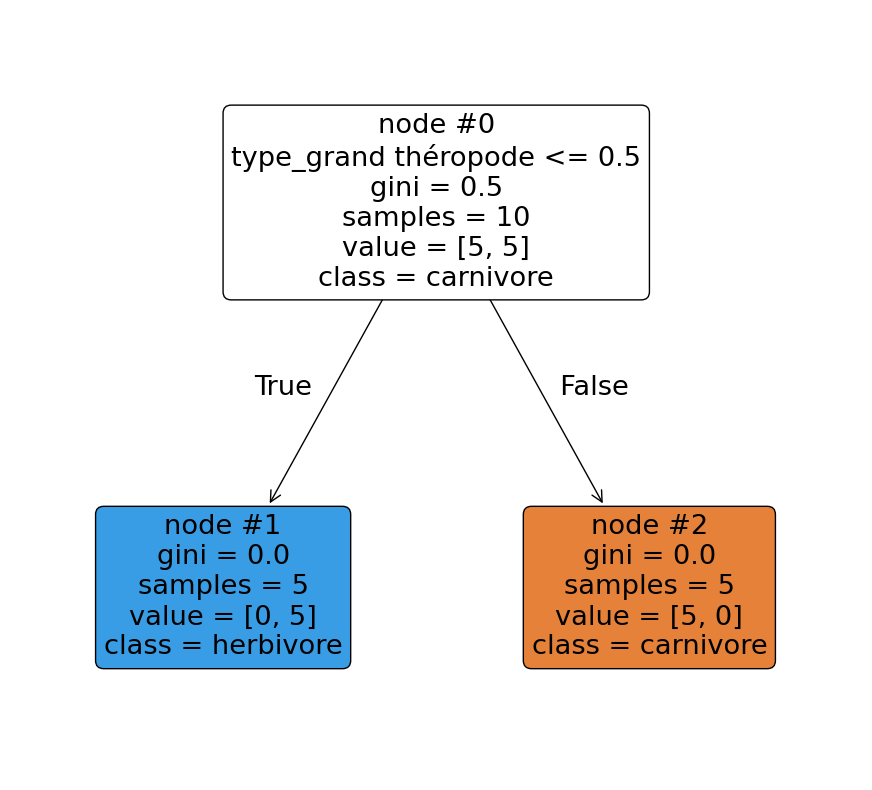

In [14]:
# Plotting resulting tree
plt.figure(figsize=(11, 10))

plot_tree(
    tree,
    feature_names=ohe.get_feature_names_out(),
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    node_ids=True
)

plt.show()

In [15]:
# Preparing testing data
X_test = df_test.drop(columns="régime_alimentaire")
X_test = ohe.transform(X_test)
y_test = df_test["régime_alimentaire"]

In [16]:
# Infering
y_pred = tree.predict(X_test)
leaf_ids = tree.apply(X_test)

results = df_test.copy()
results["prédiction"] = y_pred
results["correct"] = results["régime_alimentaire"] == results["prédiction"]
results["feuille"] = leaf_ids

display(results[[
    "régime_alimentaire",
    "prédiction",
    "correct",
    "feuille"
]])

,régime_alimentaire,prédiction,correct,feuille
0,herbivore,herbivore,True,1
1,herbivore,herbivore,True,1
2,herbivore,herbivore,True,1
3,herbivore,herbivore,True,1
4,herbivore,herbivore,True,1
5,carnivore,carnivore,True,2
6,carnivore,herbivore,False,1
7,carnivore,herbivore,False,1
8,carnivore,carnivore,True,2
9,carnivore,carnivore,True,2


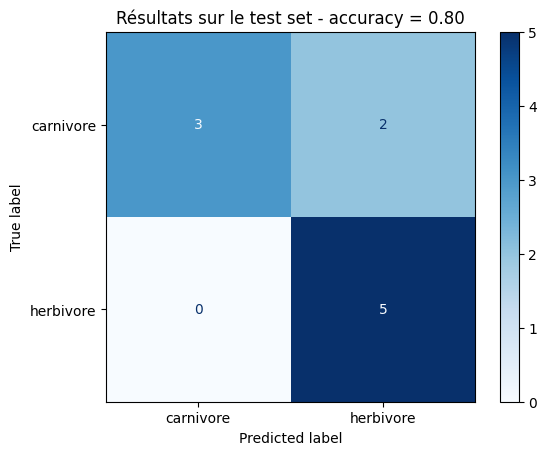

              precision    recall  f1-score   support

   carnivore       1.00      0.60      0.75         5
   herbivore       0.71      1.00      0.83         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



In [17]:
# Evaluation confusion matrix and accuracy
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=tree.classes_,
    cmap="Blues"
)

plt.title(f"Résultats sur le test set - accuracy = {accuracy_score(y_test, y_pred):.2f}")
plt.show()

print(classification_report(y_test, y_pred))

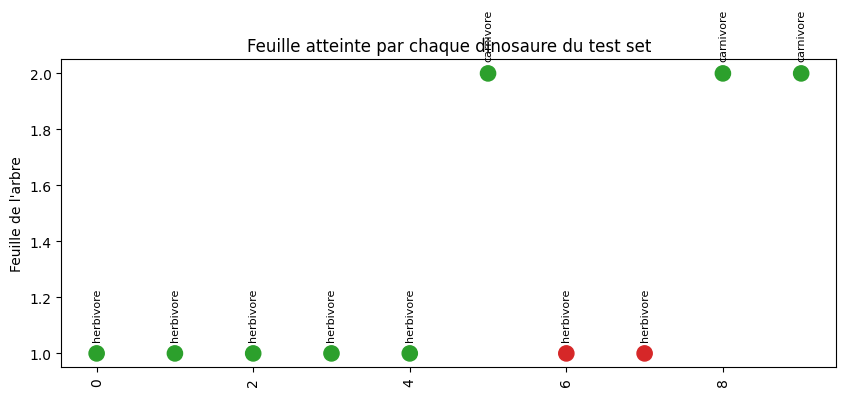

In [18]:
colors = results["correct"].map({True: "tab:green", False: "tab:red"})

plt.figure(figsize=(10, 4))
plt.scatter(results.index, results["feuille"], c=colors, s=120)

plt.xticks(rotation=90)
plt.ylabel("Feuille de l'arbre")
plt.title("Feuille atteinte par chaque dinosaure du test set")

for name, row in results.iterrows():
    plt.text(
        name,
        row["feuille"] + 0.05,
        row["prédiction"],
        rotation=90,
        ha="center",
        fontsize=8
    )

plt.show()